In [1]:
#Realizar una petición GET al sitio web de la UNO y mostrar el código de respuesta.
import requests
import pytest
import ipytest
ipytest.autoconfig()

def testElCodigoDeRespuestaEs200():
    response = requests.get("https://www.uno.edu.ar/")
    assert response.status_code == 200

ipytest.run()

.                                                                                            [100%]
1 passed in 1.67s


<ExitCode.OK: 0>

In [2]:
#Realizar una petición GET a https://httpbin.org/get y mostrar:
#código de estado
#URL de la respuesta
#contenido en texto

import requests
import pytest
import ipytest
ipytest.autoconfig()

def testPeticionesDeURL():
    response = requests.get("https://httpbin.org/get")
    assert response.status_code == 200
    assert response.url == "https://httpbin.org/get"
    assert "origin" in response.json() 

ipytest.run()

..                                                                                           [100%]
2 passed in 2.23s


<ExitCode.OK: 0>

In [3]:
#Enviar parámetros en la consulta (?nombre=Juan&edad=30) y verificar que el servidor los reciba.

import requests
import pytest
import ipytest
ipytest.autoconfig()

def testServidorRecibeLosParametros():
    response = requests.get("https://httpbin.org/get" , params={"nombre" : "juan" , "edad" : 30})
    datos = response.json()
    assert datos["args"] == {'edad': '30', 'nombre': 'juan'}

ipytest.run()

...                                                                                          [100%]
3 passed in 2.97s


<ExitCode.OK: 0>

In [10]:
#Enviar un formulario (json) con POST a https://httpbin.org/post y muestra la respuesta.
import requests
import pytest
import ipytest
ipytest.autoconfig()

def testEnvioDeFormulario():
    formulario = {
    'title': 'Título',
    'body': 'Contenido',
    'userId': 1
    }
    response = requests.post("https://httpbin.org/post", json=formulario)
    datos = response.json()
    assert datos["json"] == formulario
    assert datos["headers"]["Content-Type"] == "application/json"

ipytest.run()

.........                                                                                    [100%]
9 passed in 7.35s


<ExitCode.OK: 0>

In [9]:
#Enviar una cabecera personalizada (User-Agent) y comprueba que el servidor la reciba.
import requests
import pytest
import ipytest
ipytest.autoconfig()

def testElServidorRecibeCabeceraPersonalizada():
    nuevo_header = {"User-Agent" : "Nueva cabecera"}
    response = requests.get("https://httpbin.org/get" , headers=nuevo_header)
    datos = response.json()
    assert datos["headers"].get("User-Agent") == "Nueva cabecera"

ipytest.run()

........                                                                                     [100%]
8 passed in 6.45s


<ExitCode.OK: 0>

In [ ]:
#Descargar una imagen (https://httpbin.org/image/png) y guardarla en su disco.

import requests

response = requests.get("https://httpbin.org/image/png")
with open("chanchito.png", "wb") as archivo:
        archivo.write(response.content)
print("Se descargo la imagen")

Se descargo la imagen


In [8]:
#Ejercicio anterior rehecho para poder testear

import ipytest
import pytest
import requests
ipytest.autoconfig()

def descargar_imagen(
    ruta_destino="chanchito.png", url="https://httpbin.org/image/png"
):
    response = requests.get(url)
    with open(ruta_destino, "wb") as archivo:
        archivo.write(response.content)
    return ruta_destino

def test_descargar_imagen(tmp_path):
    archivo_temp = tmp_path / "chanchito_test.png"
    resultado = descargar_imagen(ruta_destino=str(archivo_temp))

    assert archivo_temp.exists()  #Se comprueba que el archivo exista
    assert (
        archivo_temp.stat().st_size > 0
    )  # Se comprueba que el archivo no este vacio


ipytest.run()

.......                                                                                      [100%]
7 passed in 5.90s


<ExitCode.OK: 0>

In [7]:
#Enviar una cookie (https://httpbin.org/cookies) y verificar que el servidor la reciba.

import ipytest
import pytest
import requests
ipytest.autoconfig()

def testSeVerificaQueElServidorRecibaLaCookie():
    cookie = {"galletita" : "contenido"}
    response = requests.get("https://httpbin.org/cookies" , cookies=cookie)
    datos = response.json()
    assert datos["cookies"].get("galletita") == "contenido"

ipytest.run()

......                                                                                       [100%]
6 passed in 5.19s


<ExitCode.OK: 0>

In [6]:
#Hacer una petición a https://httpbin.org/redirect/3 y analizar:
# historial (history)
# URL final (url)

import ipytest
import pytest
import requests
ipytest.autoconfig()

def testPeticion():
    response = requests.get("https://httpbin.org/redirect/3")
    assert len(response.history) == 3
    assert response.history[0].status_code == 302
    assert response.history[1].status_code == 302
    assert response.history[2].status_code == 302
    assert response.url == "https://httpbin.org/get"

ipytest.run()


.....                                                                                        [100%]
5 passed in 5.69s


<ExitCode.OK: 0>

In [5]:
#Hacer una petición a una URL inexistente y usar raise_for_status() para capturar el error.

import ipytest
import pytest
import requests
ipytest.autoconfig()

def testRaise_for_status():
    with pytest.raises(requests.exceptions.HTTPError) as exc_info:
        response = requests.get("https://httpbin.org/status/404")
        response.raise_for_status()

    assert exc_info.value.response.status_code == 404

ipytest.run()

....                                                                                         [100%]
4 passed in 3.48s


<ExitCode.OK: 0>

In [ ]:
#Crear una función que consulte una API pública (por ejemplo, https://jsonplaceholder.typicode.com/posts) y:
#Obtenga todos los posts
#Muestre los títulos
#Permita enviar un nuevo post con POST

import requests

def obtenerTodosLosPosts(pagina): 
    response = requests.get(pagina)
    return response.json()

def obtenerLosTitulos(pagina):
    salida = []
    for post in obtenerTodosLosPosts(pagina):
        salida.append(f"• {post['title']}")
    return salida

def agregarNuevoPost(pagina):
    nuevo_post = {
        'title': 'Título',
        'body': 'Contenido',
        'userId': 1
    }
    response = requests.post(pagina , json=nuevo_post)
    return response.json()

def elementosDeURL(pagina):
    return obtenerTodosLosPosts(pagina) , obtenerLosTitulos(pagina) , agregarNuevoPost(pagina)

print(elementosDeURL("https://jsonplaceholder.typicode.com/posts"))


([{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}, {'userId': 1, 'id': 2, 'title': 'qui est esse', 'body': 'est rerum tempore vitae\nsequi sint nihil reprehenderit dolor beatae ea dolores neque\nfugiat blanditiis voluptate porro vel nihil molestiae ut reiciendis\nqui aperiam non debitis possimus qui neque nisi nulla'}, {'userId': 1, 'id': 3, 'title': 'ea molestias quasi exercitationem repellat qui ipsa sit aut', 'body': 'et iusto sed quo iure\nvoluptatem occaecati omnis eligendi aut ad\nvoluptatem doloribus vel accusantium quis pariatur\nmolestiae porro eius odio et labore et velit aut'}, {'userId': 1, 'id': 4, 'title': 'eum et est occaecati', 'body': 'ullam et saepe reiciendis voluptatem adipisci\nsit amet autem assumenda provident rerum culpa\nquis hic 

In [ ]:
import requests

response = requests.get("https://jsonplaceholder.typicode.com/posts" , params={"id" : "12"})
response.json()

[{'userId': 2,
  'id': 12,
  'title': 'in quibusdam tempore odit est dolorem',
  'body': 'itaque id aut magnam\npraesentium quia et ea odit et ea voluptas et\nsapiente quia nihil amet occaecati quia id voluptatem\nincidunt ea est distinctio odio'}]

In [ ]:
import requests

def personajesDeStarWars():
    url = "https://swapi.dev/api/people/"
    while url:
        response = requests.get("https://swapi.dev/api/people/")
        data = response.json()

        for personaje in data["results"]:
            print(f"• {personaje['name']}")

        url = data.get("next")   

        if url:
            respuesta = input("Desea ver mas personajes? (s/n)").strip().lower()
            if (respuesta != "s"):
                break
        else:
            print("Llegaste a la ultima pagina")
    nombre = input("Ingresa el nombre de un personaje para buscar informacion").strip()
    personaje = requests.get("https://swapi.dev/api/people/" , params={"search" : nombre})
    info = personaje.json()["results"][0]
    print(f"\nINFORMACIÓN DE {info['name']}")
    print(f"• Altura: {info['height']} cm")
    print(f"• Año de nacimiento: {info['birth_year']}")
    print(f"• Color de ojos: {info['eye_color']}")

personajesDeStarWars()



• Luke Skywalker
• C-3PO
• R2-D2
• Darth Vader
• Leia Organa
• Owen Lars
• Beru Whitesun lars
• R5-D4
• Biggs Darklighter
• Obi-Wan Kenobi

INFORMACIÓN DE Darth Vader
• Altura: 202 cm
• Año de nacimiento: 41.9BBY
• Color de ojos: yellow


Distribucion por genero en la API de los simpsons
gender
Male       741
Female     330
Unknown    111
Name: count, dtype: int64


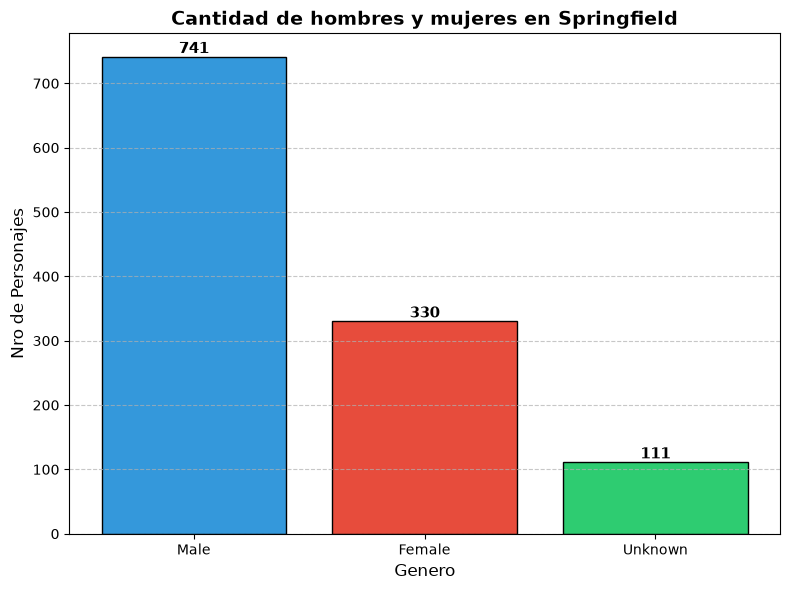

In [ ]:
#Trabajar con una API pública que le permita obtener datos, con esos datos responder alguna pregunta de interés para procesarlos (usar pandas) y luego hacer una visualización (usar matplotlib).
#La pregunta que decidi responder es cuantos hombres y cuantas mujeres hay en los simpsons

import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://thesimpsonsapi.com/api/characters"
todos_los_personajes = []

while url:
    response = requests.get(url)
    data = response.json()
    
    todos_los_personajes.extend(data.get("results", []))
    url = data.get("next")

df = pd.DataFrame(todos_los_personajes)

conteo_genero = df['gender'].value_counts()

print("Distribucion por genero en la API de los simpsons")
print(conteo_genero)

plt.figure(figsize=(8, 6))

colores = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']  # Azul para hombres, Rojo/Rosa para mujeres, etc.

barras = plt.bar(conteo_genero.index, conteo_genero.values, color=colores[:len(conteo_genero)], edgecolor='black')

plt.title('Cantidad de hombres y mujeres en Springfield', fontsize=14, fontweight='bold')
plt.xlabel('Genero', fontsize=12)
plt.ylabel('Nro de Personajes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for barra in barras:
    alto = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, alto + 0.5, str(int(alto)), 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [4]:

import requests

def obtenerNombreDePokemonPorID(id):
    response = requests.get(f"https://pokeapi.co/api/v2/pokemon/{id}")
    pokemon = response.json()
    return (pokemon["name"])

print(obtenerNombreDePokemonPorID(9))

blastoise
